In [1]:
import json
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from helpers.triplets import TripletGenerator, transform_triplets_for_embedding
from llama_index.llms.openai import OpenAI
from llama_index.core import SimpleDirectoryReader, KnowledgeGraphIndex
from llama_index.core.graph_stores import SimpleGraphStore
from llama_index.core import Settings
from IPython.display import Markdown, display
from dotenv import load_dotenv
from llama_index.core import StorageContext
from llama_index.core.schema import TextNode
from typing import List, Tuple
import os

load_dotenv("devops/env/default.env")
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

In [2]:
with open('btc_blocks.json', 'r') as f:
    blocks_data = json.load(f)

with open('economic_indicators.json', 'r') as f:
    economic_data = json.load(f)

with open('on_chain_metrics.json', 'r') as f:
    onchain_data = json.load(f)


tg = TripletGenerator()
triplets = tg.load_and_process_data(blocks_data, economic_data, onchain_data)

embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
llm = OpenAI(model="gpt-3.5-turbo-instruct", 
             temperature=0,
             api_key=OPENAI_API_KEY)
Settings.llm = llm
Settings.embed_model = embed_model

In [3]:
graph_store = SimpleGraphStore()
storage_context = StorageContext.from_defaults(graph_store=graph_store)

kg_index = KnowledgeGraphIndex(
    [],
    storage_context=storage_context,
    include_embeddings=True,
)

/tmp/ipykernel_97022/3989181565.py:4: DeprecationWarning: Call to deprecated class KnowledgeGraphIndex. (The KnowledgeGraphIndex class has been deprecated. Please use the new PropertyGraphIndex class instead. If a certain graph store integration is missing in the new class, please open an issue on the GitHub repository or contribute it!) -- Deprecated since version 0.10.53.
  kg_index = KnowledgeGraphIndex(


In [4]:

# The existing upsert_triplets performs sequential insertion including sequential embedding generation which is verrryyy slow
def batch_upsert_triplets(kg: KnowledgeGraphIndex, triplets: List[Tuple[str, str, str]], include_embeddings: bool = True) -> None:
    """Batch insert triplets with their embeddings."""
    # First insert all triplets to the graph store
    for triplet in triplets:
        kg._graph_store.upsert_triplet(*triplet)
    
    if include_embeddings:
        # Generate triplet strings for embedding
        triplet_strs = transform_triplets_for_embedding(triplets)
        
        # Get embeddings in batch
        batch_embeddings = kg._embed_model.get_text_embedding_batch(triplet_strs)
        
        # Add embeddings to the index structure
        for triplet_str, embedding in zip(triplet_strs, batch_embeddings):
            kg._index_struct.add_to_embedding_dict(triplet_str, embedding)
            
        # Update the storage
        kg._storage_context.index_store.add_index_struct(kg._index_struct)

# need to run this to update the index_struct after batch insertion
def update_index_structure_table(kg_index: KnowledgeGraphIndex):
    """
    Update the index structure table based on the graph store data.
    This is necessary for get_networkx_graph() to work properly.
    """
    # Get the graph dictionary from the graph store
    graph_dict = kg_index._graph_store._data.graph_dict
    
    # For each subject and object in the graph, add an entry to the table
    # We'll use a placeholder node ID since we don't have actual document nodes
    for subj, rel_obj_list in graph_dict.items():
        if subj not in kg_index._index_struct.table:
            kg_index._index_struct.table[subj] = set()
            
        # Add a placeholder node ID for this subject
        placeholder_id = f"entity_{subj}"
        kg_index._index_struct.table[subj].add(placeholder_id)
        
        # Also add all objects as potential subjects
        for rel, objs in rel_obj_list:
            for obj in objs:
                if obj not in kg_index._index_struct.table:
                    kg_index._index_struct.table[obj] = set()
                kg_index._index_struct.table[obj].add(f"entity_{obj}")
    
    # Update the storage
    kg_index._storage_context.index_store.add_index_struct(kg_index._index_struct)
    
    print(f"Updated index structure table with {len(kg_index._index_struct.table)} entities")

In [5]:
batch_upsert_triplets(kg_index, triplets)
update_index_structure_table(kg_index)

Updated index structure table with 6683 entities


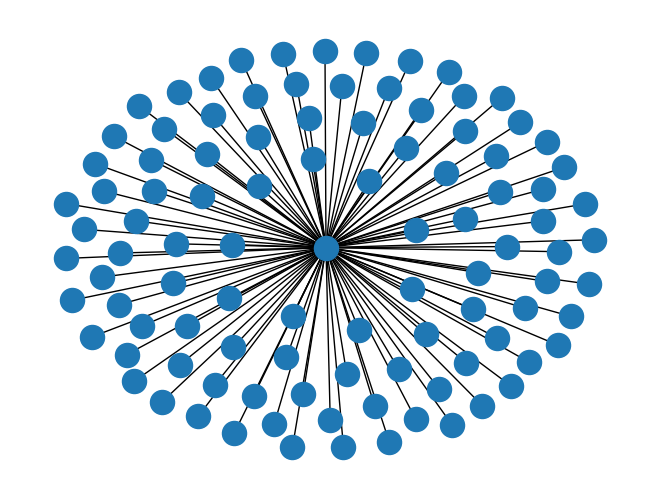

In [7]:
import networkx as nx

nx.draw(kg_index.get_networkx_graph())

In [9]:
query_engine = kg_index.as_query_engine(
    response_mode="tree_summarize",
    include_text=False,
)

In [10]:
query_engine.query("When was block 000000000000000000023175d87f3d7270a30fb4b515ea06dcb045d46f4d78ab created?")

Response(response='2025-04-26 21.11.05', source_nodes=[NodeWithScore(node=TextNode(id_='f7dfc67d-b506-418e-8acc-3a2fb50b00aa', embedding=None, metadata={'kg_rel_texts': ["('Block:894104', 'CREATED_AT', '2025-04-26 21.11.05')", "('Block:894100', 'CREATED_AT', '2025-04-26 20.51.08')"], 'kg_rel_map': {'000000000000000000023175d87f3d7270a30fb4b515ea06dcb045d46f4d78ab': [], 'block': [], 'created': []}}, excluded_embed_metadata_keys=['kg_rel_map', 'kg_rel_texts'], excluded_llm_metadata_keys=['kg_rel_map', 'kg_rel_texts'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text="The following are knowledge sequence in max depth 2 in the form of directed graph like:\n`subject -[predicate]->, object, <-[predicate_next_hop]-, object_next_hop ...`\n('Block:894104', 'CREATED_AT', '2025-04-26 21.11.05')\n('Block:894100', 'CREATED_AT', '2025-04-26 20.51.08')", mimetype='text/plain', start_char_idx=None, end_char_idx=None, metadata_seperator='\n', text_template='{metadata_

In [ ]:
query_engine.query("What was the Bitcoin Transaction Volume on 25th April 2025")

Response(response='The Bitcoin Transaction Volume on 25th April 2025 was Transaction Volume Btc.', source_nodes=[NodeWithScore(node=TextNode(id_='bff7f9e4-061f-4290-9f5d-7c04989da339', embedding=None, metadata={'kg_rel_texts': ['2025-04-25 has transaction volume btc metric Transaction Volume Btc.', 'Transaction Volume Btc has value on 2025-04-25.'], 'kg_rel_map': {'Bitcoin': [], '25th April': [], '25th': [], '2025': [], 'Volume': [], 'April': [], 'Transaction Volume': [], 'Transaction': []}}, excluded_embed_metadata_keys=['kg_rel_map', 'kg_rel_texts'], excluded_llm_metadata_keys=['kg_rel_map', 'kg_rel_texts'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='The following are knowledge sequence in max depth 2 in the form of directed graph like:\n`subject -[predicate]->, object, <-[predicate_next_hop]-, object_next_hop ...`\n2025-04-25 has transaction volume btc metric Transaction Volume Btc.\nTransaction Volume Btc has value on 2025-04-25.', mimetype

In [13]:
query_engine.query("How has the mining difficulty changed over recent blocks")

Response(response='The mining difficulty has increased over recent blocks.', source_nodes=[NodeWithScore(node=TextNode(id_='65ec548e-8015-4adf-a5f0-018c846dbc15', embedding=None, metadata={'kg_rel_texts': ['Difficulty is described as A Relative Measure Of How Difficult It Is To Find A New Block. The Difficulty Is Adjusted Periodically As A Function Of How Much Hashing Power Has Been Deployed By The Network Of Miners..', 'Difficulty has value on 2025-04-25.'], 'kg_rel_map': {'recent': [], 'changed': [], 'blocks': [], 'difficulty': [], 'mining': []}}, excluded_embed_metadata_keys=['kg_rel_map', 'kg_rel_texts'], excluded_llm_metadata_keys=['kg_rel_map', 'kg_rel_texts'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='The following are knowledge sequence in max depth 2 in the form of directed graph like:\n`subject -[predicate]->, object, <-[predicate_next_hop]-, object_next_hop ...`\nDifficulty is described as A Relative Measure Of How Difficult It Is T